In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
dados = pd.read_csv("https://raw.githubusercontent.com/cyshine/EstatESEG/main/exemplo-clusters.csv")
dados.head()

,x,y
0,9.589356,19.891227
1,8.660081,20.174640
2,9.556498,19.852315
3,11.219080,20.396321
4,10.544839,19.709607


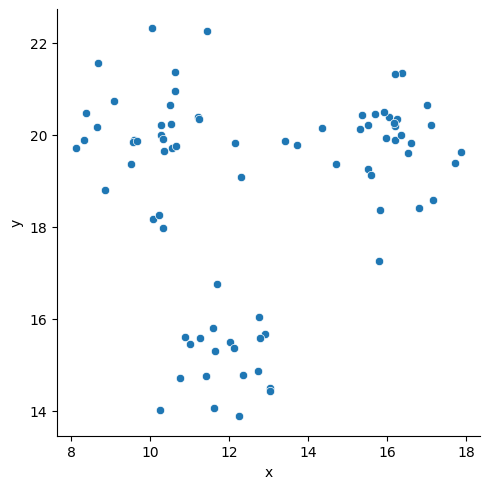

In [ ]:
sns.relplot(data = dados, x='x', y='y')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
escala = MinMaxScaler()
X = escala.fit_transform(dados)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
ss = []
for k in range(2,12):
    modelo = KMeans(n_clusters=k)
    modelo.fit(X)
    ss.append(modelo.inertia_)

In [ ]:
import matplotlib.pyplot as plt

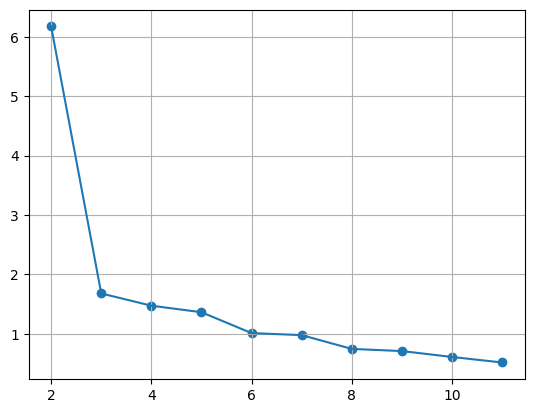

In [ ]:
plt.plot(range(2,12), ss)
plt.grid()
plt.scatter(range(2,12), ss)

In [ ]:
final = KMeans(n_clusters=3)
final.fit(X)
final.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [ ]:
dados['Grupo'] = final.labels_
dados.head()

,x,y,Grupo
0,9.589356,19.891227,1
1,8.660081,20.174640,1
2,9.556498,19.852315,1
3,11.219080,20.396321,1
4,10.544839,19.709607,1


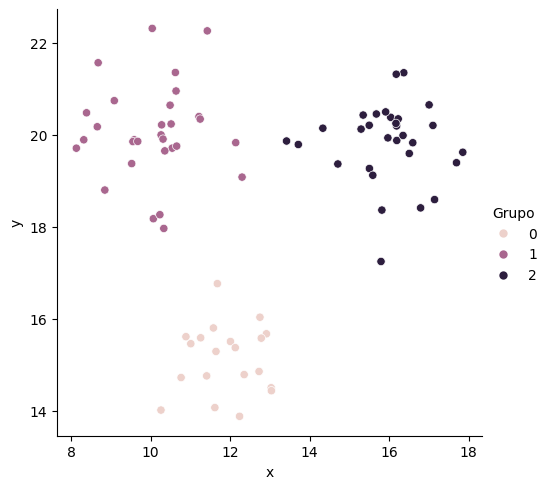

In [ ]:
sns.relplot(dados, x='x', y='y', hue='Grupo')

In [ ]:
marketing = pd.read_csv("https://raw.githubusercontent.com/cyshine/EstatESEG/main/marketing_campaign.csv", sep='\t')

In [ ]:
marketing.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
marketing.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [ ]:
marketing['Date'] = pd.to_datetime(marketing['Dt_Customer'], format='%d-%m-%Y')

In [ ]:
marketing['Date'].dt.year

,Date
0,2012
1,2014
2,2013
3,2014
4,2014
...,...
2235,2013
2236,2014
2237,2014
2238,2014


In [ ]:
marketing['Age'] = marketing['Date'].dt.year - marketing['Year_Birth']

In [ ]:
mkt = marketing.drop(['ID', 'Year_Birth', 'Date', 'Z_CostContact', 'Z_Revenue', 'Response'], axis=1)

In [ ]:
mkt.count()

,0
Education,2240
Marital_Status,2240
Income,2216
Kidhome,2240
Teenhome,2240
Dt_Customer,2240
Recency,2240
MntWines,2240
MntFruits,2240
MntMeatProducts,2240


In [ ]:
mkt.dropna(inplace=True)

In [ ]:
mkt_dummies = pd.get_dummies(mkt)

In [ ]:
escala = MinMaxScaler()
X = escala.fit_transform(mkt_dummies)

In [ ]:
X

array([[0.08483222, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.06709518, 0.5       , 0.5       , ..., 0.        , 0.        ,
        0.        ],
       [0.10509733, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.08309221, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.10153609, 0.        , 0.5       , ..., 0.        , 0.        ,
        0.        ],
       [0.07690815, 0.5       , 0.5       , ..., 0.        , 0.        ,
        0.        ]])